In [1]:
from google.colab import files
uploaded = files.upload()

Saving btc_usd_features.csv to btc_usd_features.csv


In [3]:
!pip install pygam lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.5 MB/s eta 0:00:00


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from pygam import LogisticGAM, s, f
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# Ladda BTC data
btc = pd.read_csv("btc_usd_features.csv", index_col=0, parse_dates=True)

print("Data laddad!")
print(f"Shape: {btc.shape}")
print(f"\nFeatures: {btc.columns.tolist()}")

Data laddad!
Shape: (2792, 20)

Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_50', 'MA_200', 'Golden_Cross', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff', 'BB_high', 'BB_low', 'BB_width', 'Daily_return', 'Log_return', 'High_Low_range', 'Price_change', 'Target']


In [7]:
# Features och target
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'MA_50', 'MA_200', 'Golden_Cross', 'RSI',
                'MACD', 'MACD_signal', 'MACD_diff',
                'BB_high', 'BB_low', 'BB_width',
                'Daily_return', 'Log_return',
                'High_Low_range', 'Price_change']

X = btc[feature_cols]
y = btc["Target"]

# Tidsserie-split — VIKTIGT! Ingen random shuffle för tidsserie!
split = int(len(X) * 0.8)  # 80% träning, 20% test

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Skala data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Träningsdata:  {X_train.shape}")
print(f"Testdata:      {X_test.shape}")
print(f"\nTräning från: {X_train.index[0].date()} till {X_train.index[-1].date()}")
print(f"Test från:     {X_test.index[0].date()}  till {X_test.index[-1].date()}")

Träningsdata:  (2233, 19)
Testdata:      (559, 19)

Träning från: 2018-07-19 till 2024-08-28
Test från:     2024-08-29  till 2026-03-10


In [8]:
# ── LightGBM ─────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)
lgb_pred = lgb_model.predict(X_test_scaled)

lgb_acc = accuracy_score(y_test, lgb_pred)
print(f"LightGBM Accuracy: {lgb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgb_pred))

LightGBM Accuracy: 0.5098

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.94      0.66       281
           1       0.55      0.08      0.13       278

    accuracy                           0.51       559
   macro avg       0.53      0.51      0.40       559
weighted avg       0.53      0.51      0.40       559



In [9]:
# SVM
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.5027

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.74      0.60       281
           1       0.50      0.27      0.35       278

    accuracy                           0.50       559
   macro avg       0.50      0.50      0.47       559
weighted avg       0.50      0.50      0.47       559



In [10]:
from pygam import LogisticGAM, s

# GAM — en smooth funktion per feature
gam_model = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) +
    s(5) + s(6) + s(7) + s(8) + s(9) +
    s(10) + s(11) + s(12) + s(13) + s(14) +
    s(15) + s(16) + s(17) + s(18)
)

gam_model.fit(X_train_scaled, y_train)
gam_pred = gam_model.predict(X_test_scaled)

gam_acc = accuracy_score(y_test, gam_pred)
print(f"GAM Accuracy: {gam_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gam_pred))

GAM Accuracy: 0.5027

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.98      0.66       281
           1       0.50      0.02      0.04       278

    accuracy                           0.50       559
   macro avg       0.50      0.50      0.35       559
weighted avg       0.50      0.50      0.35       559



In [11]:
# LSTM med PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Förbered sekvens-data för LSTM ───────────────────
def create_sequences(X, y, seq_length=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values,  seq_length)

# Konvertera till PyTorch tensors
X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.FloatTensor(y_train_seq)
X_test_t  = torch.FloatTensor(X_test_seq)
y_test_t  = torch.FloatTensor(y_test_seq)

print(f"LSTM träningsdata: {X_train_t.shape}")
print(f"LSTM testdata:     {X_test_t.shape}")

LSTM träningsdata: torch.Size([2203, 30, 19])
LSTM testdata:     torch.Size([529, 30, 19])


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5027

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.95      0.66       281
           1       0.50      0.05      0.09       278

    accuracy                           0.50       559
   macro avg       0.50      0.50      0.37       559
weighted avg       0.50      0.50      0.37       559



In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Förbered sekvens-data ─────────────────────────────
def create_sequences(X, y, seq_length=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values,  seq_length)

X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.FloatTensor(y_train_seq)
X_test_t  = torch.FloatTensor(X_test_seq)
y_test_t  = torch.FloatTensor(y_test_seq)

# ── LSTM Modell ───────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# ── Träning med Early Stopping ────────────────────────
model     = LSTMModel(input_size=19, hidden_size=64, num_layers=2)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs     = 100
batch_size = 32
patience   = 10   # Stoppa om ingen förbättring efter 10 epochs

dataset = TensorDataset(X_train_t, y_train_t)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

best_loss        = float('inf')
patience_counter = 0
best_model       = None

print("Tränar LSTM med Early Stopping...")
for epoch in range(epochs):
    # ── Träning ──
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    # ── Validering ──
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_t).squeeze()
        val_loss   = criterion(val_output, y_test_t).item()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {avg_loss:.4f} — Val Loss: {val_loss:.4f}")

    # ── Early Stopping ──
    if val_loss < best_loss:
        best_loss        = val_loss
        best_model       = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹ Early stopping vid epoch {epoch+1}!")
            print(f"Bästa val loss: {best_loss:.4f}")
            break

# Ladda bästa modellen
model.load_state_dict(best_model)
print("\n✅ LSTM tränad med Early Stopping!")

Tränar LSTM med Early Stopping...
Epoch 5/100 — Train Loss: 0.6912 — Val Loss: 0.6939
Epoch 10/100 — Train Loss: 0.6821 — Val Loss: 0.6988

⏹ Early stopping vid epoch 11!
Bästa val loss: 0.6928

✅ LSTM tränad med Early Stopping!


In [15]:
# Utvärdera LSTM
model.eval()
with torch.no_grad():
    lstm_output = model(X_test_t).squeeze()
    lstm_pred   = (lstm_output > 0.5).float().numpy()

lstm_acc = accuracy_score(y_test_seq, lstm_pred)
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, lstm_pred))

LSTM Accuracy: 0.5047

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.86      0.64       269
           1       0.49      0.14      0.22       260

    accuracy                           0.50       529
   macro avg       0.50      0.50      0.43       529
weighted avg       0.50      0.50      0.43       529



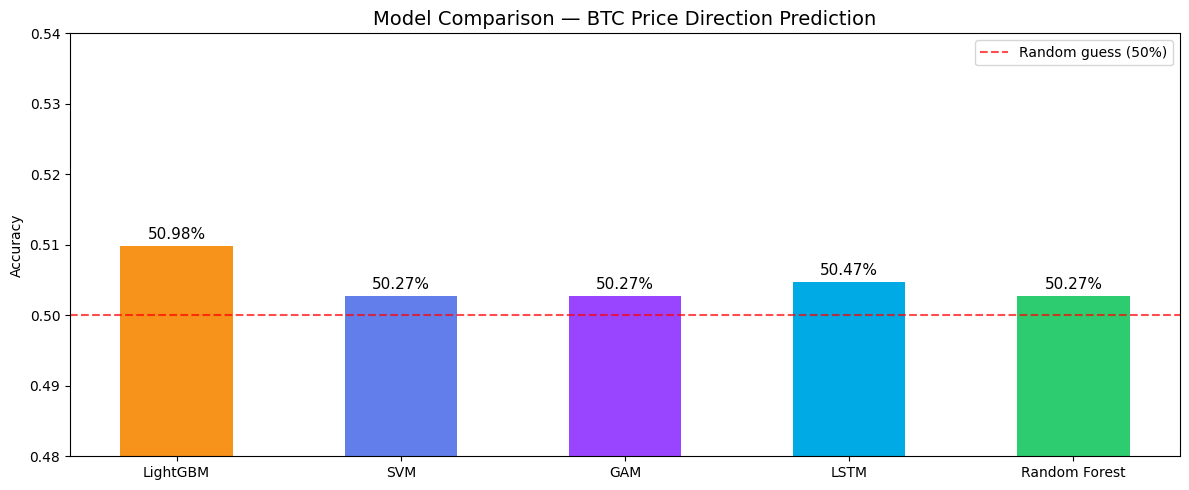


🏆 RANKING:
1. LightGBM: 50.98%
2. LSTM: 50.47%
3. SVM: 50.27%
4. GAM: 50.27%
5. Random Forest: 50.27%


In [20]:
# jämförelse
models = ['LightGBM', 'SVM', 'GAM', 'LSTM', 'Random Forest']
scores = [lgb_acc, svm_acc, gam_acc, lstm_acc, rf_acc]
colors = ['#F7931A', '#627EEA', '#9945FF', '#00AAE4', '#2ECC71']

plt.figure(figsize=(12, 5))
bars = plt.bar(models, scores, color=colors, width=0.5)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Random guess (50%)')
plt.ylim(0.48, 0.54)
plt.title('Model Comparison — BTC Price Direction Prediction', fontsize=14)
plt.ylabel('Accuracy')
plt.legend()

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Ranking
print("\n🏆 RANKING:")
ranking = sorted(zip(models, scores), key=lambda x: x[1], reverse=True)
for i, (model, score) in enumerate(ranking, 1):
    print(f"{i}. {model}: {score:.2%}")

In [17]:
# Prediktera imorgon för alla 4 modeller
senaste_data = X_test_scaled[-30:]
senaste_tensor = torch.FloatTensor(senaste_data).unsqueeze(0)

# LSTM
model.eval()
with torch.no_grad():
    lstm_prob = model(senaste_tensor).item()

# LightGBM, SVM, GAM
lgb_prob = lgb_model.predict_proba(X_test_scaled[-1:])[0][1]
svm_prob = svm_model.decision_function(X_test_scaled[-1:])[0]
gam_prob = gam_model.predict_proba(X_test_scaled[-1:])[0]

print("=" * 45)
print("   BTC PREDIKTION FÖR IMORGON 🔮")
print("=" * 45)
print(f"LightGBM: {'📈 UPP' if lgb_prob > 0.5 else '📉 NED'} ({lgb_prob:.2%})")
print(f"LSTM:     {'📈 UPP' if lstm_prob > 0.5 else '📉 NED'} ({lstm_prob:.2%})")
print(f"GAM:      {'📈 UPP' if gam_prob > 0.5 else '📉 NED'} ({gam_prob:.2%})")
print("=" * 45)

# Majoritetsvote
probs = [lgb_prob, lstm_prob, gam_prob]
avg = sum(probs) / len(probs)
print(f"\nKonsensus: {'📈 UPP' if avg > 0.5 else '📉 NED'} ({avg:.2%})")

   BTC PREDIKTION FÖR IMORGON 🔮
LightGBM: 📉 NED (7.59%)
LSTM:     📉 NED (46.69%)
GAM:      📉 NED (0.29%)

Konsensus: 📉 NED (18.19%)
